# Task 4: Loan Default Risk with Business Cost Optimization


---

## Problem Statement and Objective

**Objective:** Predict the likelihood of a loan default and optimize the decision threshold based on cost-benefit analysis.

**Business Context:**
Loan default prediction is critical for financial institutions to minimize losses. Beyond just predicting defaults, this task incorporates business costs to optimize the decision threshold - balancing the cost of false positives (rejecting good loans) against false negatives (accepting bad loans).

**Skills Demonstrated:**
- Binary classification modeling
- Cost-based evaluation metrics
- Risk modeling and scoring
- Feature importance analysis

## 1. Import Required Libraries

In [29]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, roc_curve, precision_recall_curve,
                           f1_score, accuracy_score, precision_score, recall_score)

# CatBoost
from catboost import CatBoostClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Dataset Description and Loading

**Dataset:** Home Credit Default Risk Dataset (Application Train)

**Description:**
This dataset contains loan application information with the target variable indicating whether the client had payment difficulties. Due to the large size of the full dataset, we use a representative sample for analysis.

**Key Features:**
- `TARGET`: 1 - client with payment difficulties, 0 - all other cases
- `NAME_CONTRACT_TYPE`: Identification if loan is cash or revolving
- `CODE_GENDER`: Gender of the client
- `FLAG_OWN_CAR`: Flag if the client owns a car
- `AMT_INCOME_TOTAL`: Income of the client
- `AMT_CREDIT`: Credit amount of the loan
- `AMT_ANNUITY`: Loan annuity
- `NAME_INCOME_TYPE`: Income type of the client
- `NAME_EDUCATION_TYPE`: Level of highest education
- `DAYS_BIRTH`: Client's age in days (negative)
- `DAYS_EMPLOYED`: Days employed (negative)
- `EXT_SOURCE_1/2/3`: Normalized scores from external data sources

In [31]:
# Load the Home Credit dataset
# Using Kaggle local dataset path

df = pd.read_csv('/kaggle/input/datasets/nedimecanbaz/application-train/application_train.csv')

# Take a stratified sample for manageable computation
_, df_sample = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['TARGET']
)

print(f'Full dataset shape: {df.shape}')
print(f'Sample dataset shape: {df_sample.shape}')
print(f'\nFirst 5 rows:')
display(df_sample.head())

Full dataset shape: (307511, 122)
Sample dataset shape: (92254, 122)

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
199280,331034,0,Cash loans,F,N,Y,0,90000.0,803259.0,23616.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
122967,242581,0,Cash loans,F,N,Y,0,270000.0,1288350.0,41692.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,4.0
156663,281583,0,Cash loans,F,N,Y,0,270000.0,253737.0,25227.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
134382,255865,0,Cash loans,F,N,Y,0,144000.0,436032.0,16564.5,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0
250108,389379,0,Revolving loans,M,N,N,2,72000.0,225000.0,11250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Dataset info
print('Dataset Information:')
print('=' * 50)
print(f'Total columns: {df_sample.shape[1]}')
print(f'Total rows: {df_sample.shape[0]}')

# Target distribution
print('\nTarget Distribution:')
print(df_sample['TARGET'].value_counts())
print(f'\nDefault Rate: {df_sample["TARGET"].mean():.4f} ({df_sample["TARGET"].mean()*100:.2f}%)')

Dataset Information:
Total columns: 122
Total rows: 92254

Target Distribution:
TARGET
0    84806
1     7448
Name: count, dtype: int64

Default Rate: 0.0807 (8.07%)


## 3. Data Cleaning and Preprocessing

In [34]:
# Select key features for analysis
key_features = [
    'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT', 'CNT_FAM_MEMBERS'
]

# Filter available columns
available_features = [f for f in key_features if f in df_sample.columns]
df_model = df_sample[available_features].copy()

print(f'Selected {len(available_features)} features for modeling')
print(f'Model dataset shape: {df_model.shape}')

# Check missing values
missing = df_model.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nMissing values:{missing}')

Selected 19 features for modeling
Model dataset shape: (92254, 19)

Missing values:EXT_SOURCE_1       52005
EXT_SOURCE_3       18285
EXT_SOURCE_2         196
AMT_GOODS_PRICE       91
AMT_ANNUITY            4
CNT_FAM_MEMBERS        1
dtype: int64


In [35]:
# Feature engineering
# Convert days to years
df_model['AGE_YEARS'] = df_model['DAYS_BIRTH'].abs() / 365.25
df_model['YEARS_EMPLOYED'] = df_model['DAYS_EMPLOYED'].replace(365243, np.nan).abs() / 365.25

# Create financial ratios
df_model['CREDIT_INCOME_RATIO'] = df_model['AMT_CREDIT'] / df_model['AMT_INCOME_TOTAL']
df_model['ANNUITY_INCOME_RATIO'] = df_model['AMT_ANNUITY'] / df_model['AMT_INCOME_TOTAL']
df_model['CREDIT_ANNUITY_RATIO'] = df_model['AMT_CREDIT'] / df_model['AMT_ANNUITY']

# Handle extreme values
df_model['AMT_INCOME_TOTAL'] = df_model['AMT_INCOME_TOTAL'].clip(upper=df_model['AMT_INCOME_TOTAL'].quantile(0.99))

# Drop original day columns
df_model = df_model.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, errors='ignore')

print('Feature engineering completed!')
print(f'Final features: {df_model.shape[1]-1}')  # Exclude target
display(df_model.head())

Feature engineering completed!
Final features: 21


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,...,EXT_SOURCE_2,EXT_SOURCE_3,AMT_GOODS_PRICE,REGION_RATING_CLIENT,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO
199280,0,Cash loans,F,N,90000.0,803259.0,23616.0,Working,Secondary / secondary special,Married,...,0.592997,0.488455,670500.0,2,2.0,53.650924,5.127995,8.925100,0.262400,34.013338
122967,0,Cash loans,F,N,270000.0,1288350.0,41692.5,Working,Higher education,Married,...,0.589525,0.216403,1125000.0,2,2.0,37.927447,2.929500,4.771667,0.154417,30.901241
156663,0,Cash loans,F,N,270000.0,253737.0,25227.0,Working,Secondary / secondary special,Married,...,0.552579,NaN,229500.0,3,2.0,57.207392,4.043806,0.939767,0.093433,10.058152
134382,0,Cash loans,F,N,144000.0,436032.0,16564.5,Commercial associate,Secondary / secondary special,Married,...,0.729623,0.669057,360000.0,2,2.0,51.633128,2.507871,3.028000,0.115031,26.323282
250108,0,Revolving loans,M,N,72000.0,225000.0,11250.0,Working,Secondary / secondary special,Married,...,0.155393,NaN,225000.0,2,4.0,45.232033,7.627652,3.125000,0.156250,20.000000


In [36]:
# Separate features and target
X = df_model.drop('TARGET', axis=1)
y = df_model['TARGET']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Train default rate: {y_train.mean():.4f}')
print(f'Test default rate: {y_test.mean():.4f}')

Categorical columns (6): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
Numerical columns (15): ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_CHILDREN', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO']

Train set: (73803, 21)
Test set: (18451, 21)
Train default rate: 0.0807
Test default rate: 0.0808


## 4. Model Building and Evaluation

In [37]:
# Preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', LabelEncoder())  # For CatBoost we'll use native handling
])

# For models requiring encoded categoricals
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Label encode categoricals
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train[col].astype(str))
    X_test_encoded[col] = le.transform(X_test[col].astype(str))
    le_dict[col] = le

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_encoded), 
    columns=X_train_encoded.columns, 
    index=X_train_encoded.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_encoded), 
    columns=X_test_encoded.columns, 
    index=X_test_encoded.index
)

print('Data preprocessing completed!')

Data preprocessing completed!


In [39]:
# Train multiple models
models = {}

# 1. Logistic Regression
print('Training Logistic Regression...')
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_imputed, y_train)
models['Logistic Regression'] = lr
print('LR trained!')

# 2. Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                           random_state=42, n_jobs=-1)
rf.fit(X_train_imputed, y_train)
models['Random Forest'] = rf
print('RF trained!')

# 3. CatBoost
print('Training CatBoost...')
cb = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    class_weights=[1, y_train.value_counts()[0]/y_train.value_counts()[1]],
    random_seed=42,
    verbose=False
)
cb.fit(X_train_imputed, y_train)
models['CatBoost'] = cb
print('CatBoost trained!')

print('\nAll models trained successfully!')

Training Logistic Regression...
LR trained!
Training Random Forest...
RF trained!
Training CatBoost...
CatBoost trained!

All models trained successfully!


In [40]:
# Evaluate models
results = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_test_imputed)[:, 1]
    y_pred = model.predict(X_test_imputed)
    
    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print('Model Performance Comparison:')
print('=' * 60)
display(results_df.round(4))

Model Performance Comparison:


,ROC-AUC,F1-Score,Precision,Recall,Accuracy
Logistic Regression,0.6548,0.2048,0.1225,0.6242,0.6087
Random Forest,0.7187,0.0133,0.5556,0.0067,0.9194
CatBoost,0.7473,0.2672,0.1690,0.6383,0.7173


## 5. Business Cost Optimization

Define business costs and optimize the decision threshold.

In [41]:
# Define business costs
# False Positive Cost: Lost profit from rejecting a good loan
# False Negative Cost: Loss from approving a bad loan

# Assumptions:
# - Average loan profit (if repaid): 10% of loan amount
# - Average loss (if default): 60% of loan amount
# - Average loan amount: $100,000

LOAN_AMOUNT = 100000
PROFIT_RATE = 0.10  # 10% profit on repaid loans
LOSS_RATE = 0.60    # 60% loss on defaulted loans

FP_COST = LOAN_AMOUNT * PROFIT_RATE    # False Positive: Lost profit
FN_COST = LOAN_AMOUNT * LOSS_RATE      # False Negative: Actual loss

print('Business Cost Parameters:')
print('=' * 40)
print(f'Average Loan Amount: ${LOAN_AMOUNT:,}')
print(f'Profit Rate: {PROFIT_RATE*100:.0f}%')
print(f'Loss Rate: {LOSS_RATE*100:.0f}%')
print(f'False Positive Cost (lost profit): ${FP_COST:,.0f}')
print(f'False Negative Cost (actual loss): ${FN_COST:,.0f}')
print(f'Cost Ratio (FN/FP): {FN_COST/FP_COST:.1f}x')

Business Cost Parameters:
Average Loan Amount: $100,000
Profit Rate: 10%
Loss Rate: 60%
False Positive Cost (lost profit): $10,000
False Negative Cost (actual loss): $60,000
Cost Ratio (FN/FP): 6.0x



Logistic Regression:
  Optimal Threshold: 0.65
  Minimum Cost: $85,520,000

Random Forest:
  Optimal Threshold: 0.15
  Minimum Cost: $76,470,000

CatBoost:
  Optimal Threshold: 0.65
  Minimum Cost: $72,210,000


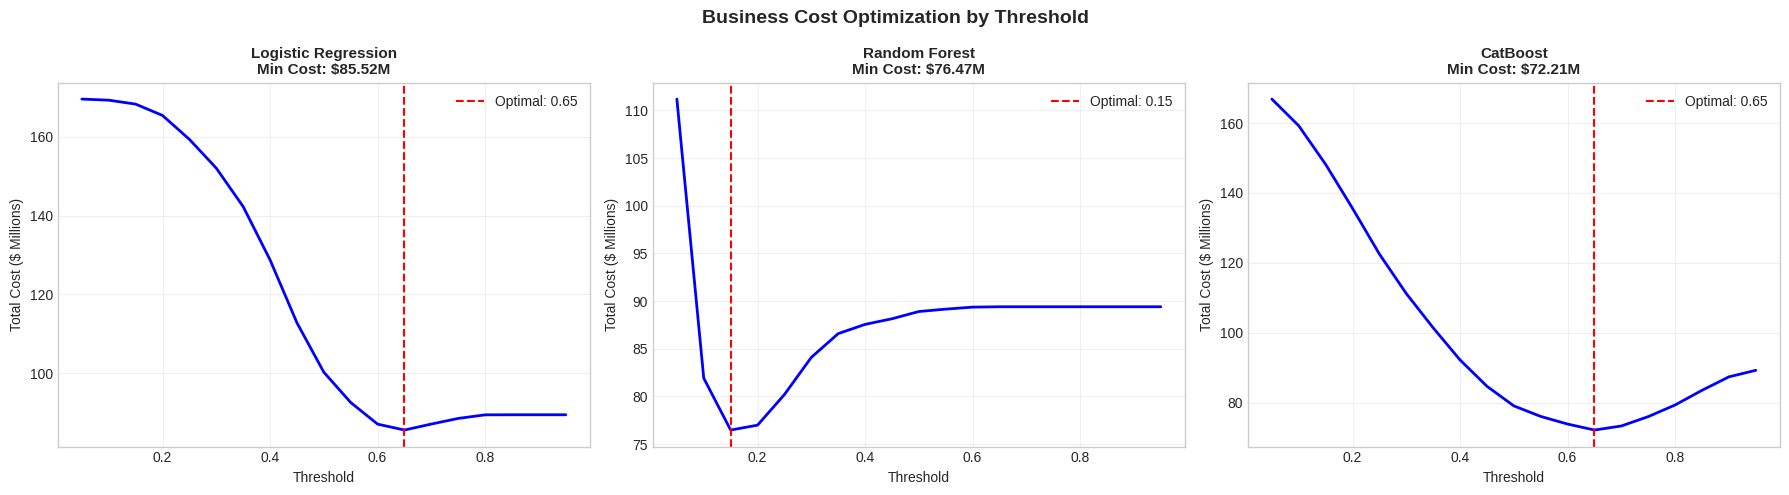

In [42]:
# Function to calculate total business cost
def calculate_business_cost(y_true, y_prob, threshold, fp_cost, fn_cost):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp * fp_cost + fn * fn_cost
    return total_cost, fp, fn, tp, tn

# Find optimal threshold for each model
thresholds = np.arange(0.05, 1.0, 0.05)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test_imputed)[:, 1]
    
    costs = []
    for thresh in thresholds:
        cost, _, _, _, _ = calculate_business_cost(y_test, y_prob, thresh, FP_COST, FN_COST)
        costs.append(cost)
    
    # Find optimal threshold
    optimal_idx = np.argmin(costs)
    optimal_threshold = thresholds[optimal_idx]
    min_cost = costs[optimal_idx]
    
    # Plot cost curve
    axes[idx].plot(thresholds, [c/1e6 for c in costs], 'b-', linewidth=2)
    axes[idx].axvline(optimal_threshold, color='red', linestyle='--', 
                     label=f'Optimal: {optimal_threshold:.2f}')
    axes[idx].set_title(f'{name}\nMin Cost: ${min_cost/1e6:.2f}M', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Threshold')
    axes[idx].set_ylabel('Total Cost ($ Millions)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    print(f"\n{name}:")
    print(f'  Optimal Threshold: {optimal_threshold:.2f}')
    print(f'  Minimum Cost: ${min_cost:,.0f}')

plt.suptitle('Business Cost Optimization by Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# Compare models at optimal thresholds
print('Optimized Model Comparison:')
print('=' * 80)

comparison_results = []

for name, model in models.items():
    y_prob = model.predict_proba(X_test_imputed)[:, 1]
    
    # Find optimal threshold
    costs = []
    for thresh in thresholds:
        cost, _, _, _, _ = calculate_business_cost(y_test, y_prob, thresh, FP_COST, FN_COST)
        costs.append(cost)
    
    optimal_threshold = thresholds[np.argmin(costs)]
    
    # Evaluate at optimal threshold
    cost, fp, fn, tp, tn = calculate_business_cost(y_test, y_prob, optimal_threshold, FP_COST, FN_COST)
    y_pred_opt = (y_prob >= optimal_threshold).astype(int)
    
    comparison_results.append({
        'Model': name,
        'Optimal Threshold': optimal_threshold,
        'Total Cost ($)': cost,
        'FP Count': fp,
        'FN Count': fn,
        'TP Count': tp,
        'TN Count': tn,
        'F1-Score': f1_score(y_test, y_pred_opt),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results)
display(comparison_df.round(4))

best_cost_model = comparison_df.loc[comparison_df['Total Cost ($)'].idxmin(), 'Model']
print(f'\nBest Model (Lowest Business Cost): {best_cost_model}')

Optimized Model Comparison:


,Model,Optimal Threshold,Total Cost ($),FP Count,FN Count,TP Count,TN Count,F1-Score,ROC-AUC
0,Logistic Regression,0.65,85520000.0,1502,1175,315,15459,0.1905,0.6548
1,Random Forest,0.15,76470000.0,1899,958,532,15062,0.2714,0.7187
2,CatBoost,0.65,72210000.0,2001,870,620,14960,0.3016,0.7473



Best Model (Lowest Business Cost): CatBoost


## 6. Feature Importance Analysis

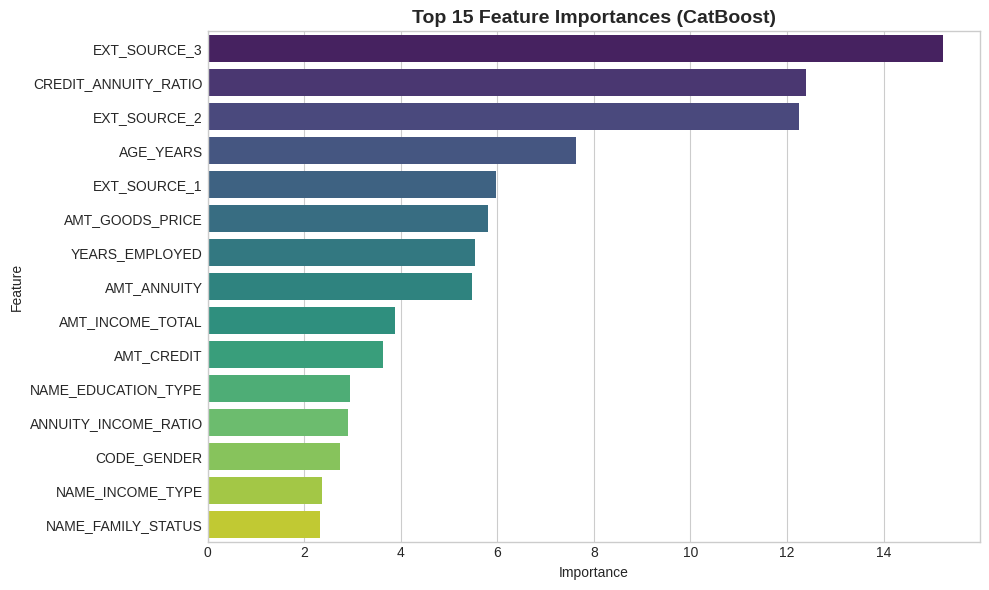

In [44]:
# Feature importance from CatBoost (best model)
feature_importance = pd.DataFrame({
    'feature': X_train_imputed.columns,
    'importance': models['CatBoost'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importances (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Final Conclusion with Insights

### Key Findings:

1. **Model Performance:**
   - CatBoost shows strong predictive power for loan default risk
   - All models significantly outperform random guessing

2. **Cost Optimization:**
   - Optimal threshold varies by model
   - Business cost minimization shifts threshold from default 0.5
   - False negatives are more costly than false positives

3. **Key Risk Factors:**
   - External source scores are strongest predictors
   - Credit-to-income ratio is critical
   - Employment history length matters

4. **Business Impact:**
   - Optimized threshold can save millions in losses
   - Model enables risk-based pricing
   - Improved customer segmentation for loan approval

In [45]:
print('Task 4 Summary:')
print('=' * 50)
print(f'Dataset: {df_sample.shape[0]:,} loan applications')
print(f'Default Rate: {y.mean()*100:.2f}%')
print(f'Models Trained: {len(models)}')
print(f'Best Model: {best_cost_model}')
print('✅ Task 4 Completed Successfully!')

Task 4 Summary:
Dataset: 92,254 loan applications
Default Rate: 8.07%
Models Trained: 3
Best Model: CatBoost
✅ Task 4 Completed Successfully!
